# Imports 

In [1]:
%load_ext autoreload
%autoreload 2


import sys
sys.path.append("/tf/ProjectGabriel/teixeira24-delve-dr2-phz/")

import pickle 
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.patches as mpatches
from matplotlib import cm
from matplotlib.colors import Normalize 
from scipy.interpolate import interpn
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from utils.beauty import plt_style
from tqdm import tqdm
import os
import sys
from utils.analysis import h2dplot, metrics_per_bin


# Loading Results

In [2]:
# Paths
RESULTS_DIR = os.path.join(f'/tf/astrodados/Results/DELVE_DR2_MDN_GRZ/')#RESULTS_DIR = '../results/griz/'
TRAIN_PATH = f'/tf/astrodados/Datasets/DELVE_DR2_train_flat_GRIZ.csv'#TRAIN_PATH = '../data/dlcat/dltrain_a.csv'
TEST_PATH = f'/tf/astrodados/Datasets/DELVE_DR2_test_flat_GRIZ.csv'#TEST_PATH  = '../data/dlcat/test_data.csv'

# Parameters
N_FOLDS = 1 # 5
ZAXIS   = np.linspace(0, 2, 2000)
SCALER  = StandardScaler()

# Fold names
folds = [f'fold_{j}' for j in range(N_FOLDS)]

# Containers
My_PDFs   = {}
My_Photoz = {}
My_Errors = {}
My_Fits_A = {}

# Load test data
TEST_DATA = pd.read_csv(TEST_PATH)

# Load results per fold
for j in tqdm(range(N_FOLDS)):
    fold_name = folds[j]
    fold_dir  = os.path.join(RESULTS_DIR, fold_name)

    My_PDFs[fold_name] = np.load(os.path.join(fold_dir, 'my_pdfs.npy'))
    My_Photoz[fold_name] = np.load(os.path.join(fold_dir, 'my_photoz.npy'))
    My_Errors[fold_name] = np.load(os.path.join(fold_dir, 'my_zerr.npy'))

    with open(os.path.join(RESULTS_DIR, fold_name, 'history.pkl'), 'rb') as fp:
        My_Fits_A[fold_name] = pickle.load(fp)


100%|██████████| 1/1 [00:01<00:00,  1.93s/it]


# Loss Curve

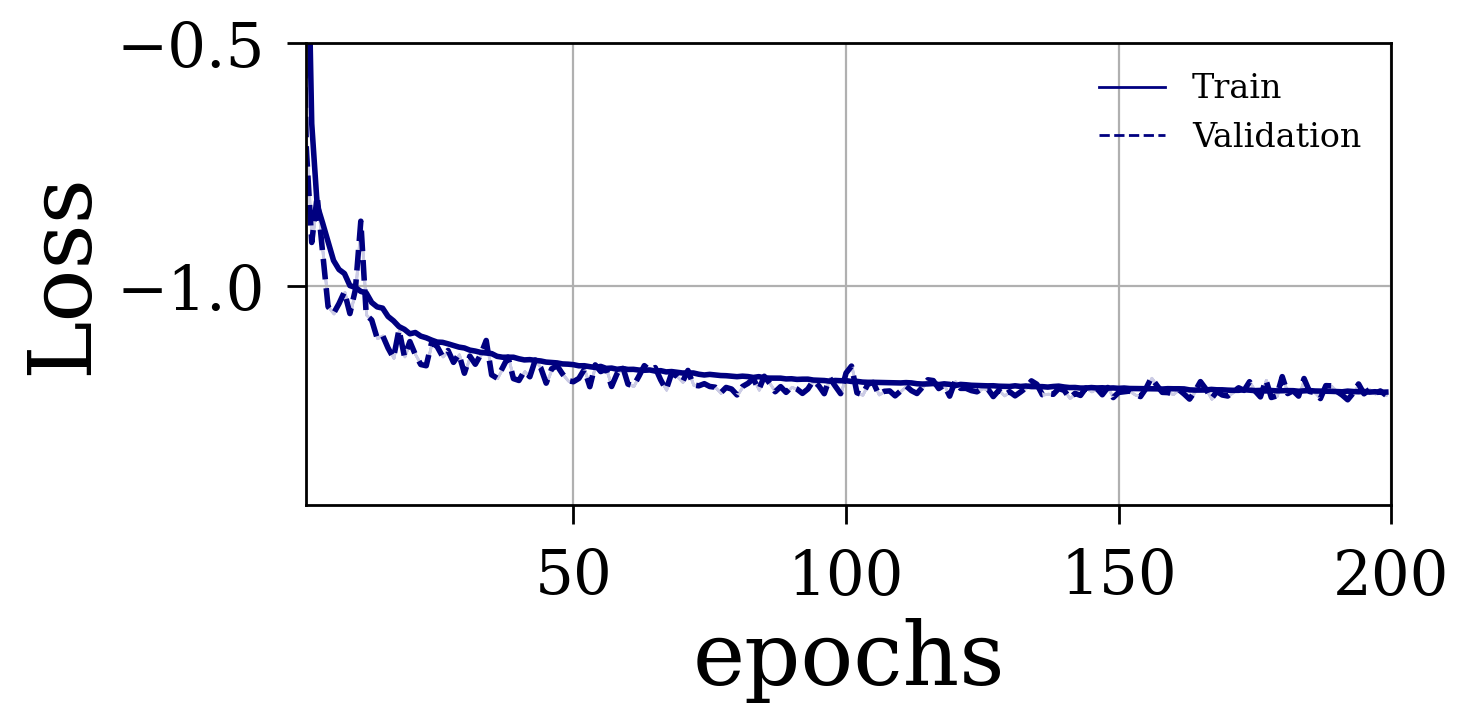

In [3]:
# GRIZ — DLTRAIN-A only

loss_mean_DR2_A = {}
loss_std_DR2_A = {}

for xn in ['loss', 'val_loss']:
    aux_list = [My_Fits_A[folds[j]][xn] for j in range(N_FOLDS)]
    stacked = np.vstack(aux_list)
    loss_mean_DR2_A[xn] = np.mean(stacked, axis=0)
    loss_std_DR2_A[xn] = np.std(stacked, axis=0)

plt_style()
fig, ax = plt.subplots(figsize=(7, 3), dpi=200)

loss_range = np.arange(len(loss_mean_DR2_A['loss']))

A_style = {
    'loss': {
        'color': 'navy',
        'ls': '-',
        'lw': 2,
        'label': 'DLTRAIN-A - MDN'
    },
    'val_loss': {
        'color': 'navy',
        'ls': '--',
        'lw': 2,
        'label': 'DLTRAIN-A - MDN'
    }
}

for xn in ['loss', 'val_loss']:
    ax.plot(loss_range, loss_mean_DR2_A[xn], **A_style[xn])
    ax.fill_between(
        loss_range,
        loss_mean_DR2_A[xn] - loss_std_DR2_A[xn],
        loss_mean_DR2_A[xn] + loss_std_DR2_A[xn],
        color=A_style[xn]['color'],
        alpha=0.2
    )

ax.grid()
ax.set_xlim(1, 200)
ax.set_ylim(-1.45, -0.5)

solid = mpl.lines.Line2D([], [], ls='-', c='navy')
dashed = mpl.lines.Line2D([], [], ls='--', c='navy')

ax.set_xlabel('epochs')
ax.set_ylabel('Loss')

plt.legend(
    handles=[solid, dashed],
    labels=['Train', 'Validation'],
    fontsize=12
)

plt.savefig('../figures/losses.pdf', bbox_inches='tight')


# Point-Like Metrics


In [4]:

My_Metrics_DR2 = {}
bins_DR2= {}

possible_axis = ['zspec','zphot','rmag']

for xaxis in possible_axis:
    My_Metrics_DR2[xaxis] = {}
     
    for j in range(N_FOLDS):
        print(folds[j].upper())

        My_Metrics_DR2[xaxis][folds[j]], bins_DR2[xaxis] = metrics_per_bin(TEST_DATA['Z'],
                                                          My_Photoz[folds[j]],
                                                          zwidth=.05,
                                                          rmag=TEST_DATA['MAG_AUTO_R'],
                                                          magwidth=0.5,
                                                          xaxis=xaxis, zlim=1)

        
        


FOLD_0
FOLD_0
FOLD_0


/usr/local/lib/python3.11/dist-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/usr/local/lib/python3.11/dist-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/tf/ProjectGabriel/teixeira24-delve-dr2-phz/utils/analysis.py:73: RuntimeWarning: invalid value encountered in scalar divide
  outlier_frac_point = np.sum(  np.abs(delta_z)/(1+zspec_bin) >0.15)/len(delta_z)


In [5]:

metrics_mean_DR2 = {}
metrics_std_DR2 = {}
for xaxis in possible_axis:
    metrics_mean_DR2[xaxis] = {}

    metrics_std_DR2[xaxis] = {}
    
    for xn in My_Metrics_DR2['zspec'][folds[0]]:
        print(xn)
        aux_list = [np.array(My_Metrics_DR2[xaxis][folds[j]][xn]) for j in range(N_FOLDS)]

        metrics_mean_DR2[xaxis][xn] = np.mean(np.vstack(aux_list), axis=0)
        metrics_std_DR2[xaxis][xn] = np.zeros(len(aux_list[0]))#np.mean(np.vstack(aux_list), axis=0)


$\sigma_{NMAD}$
mean bias
median bias
outfrac
$\sigma_{NMAD}$
mean bias
median bias
outfrac
$\sigma_{NMAD}$
mean bias
median bias
outfrac


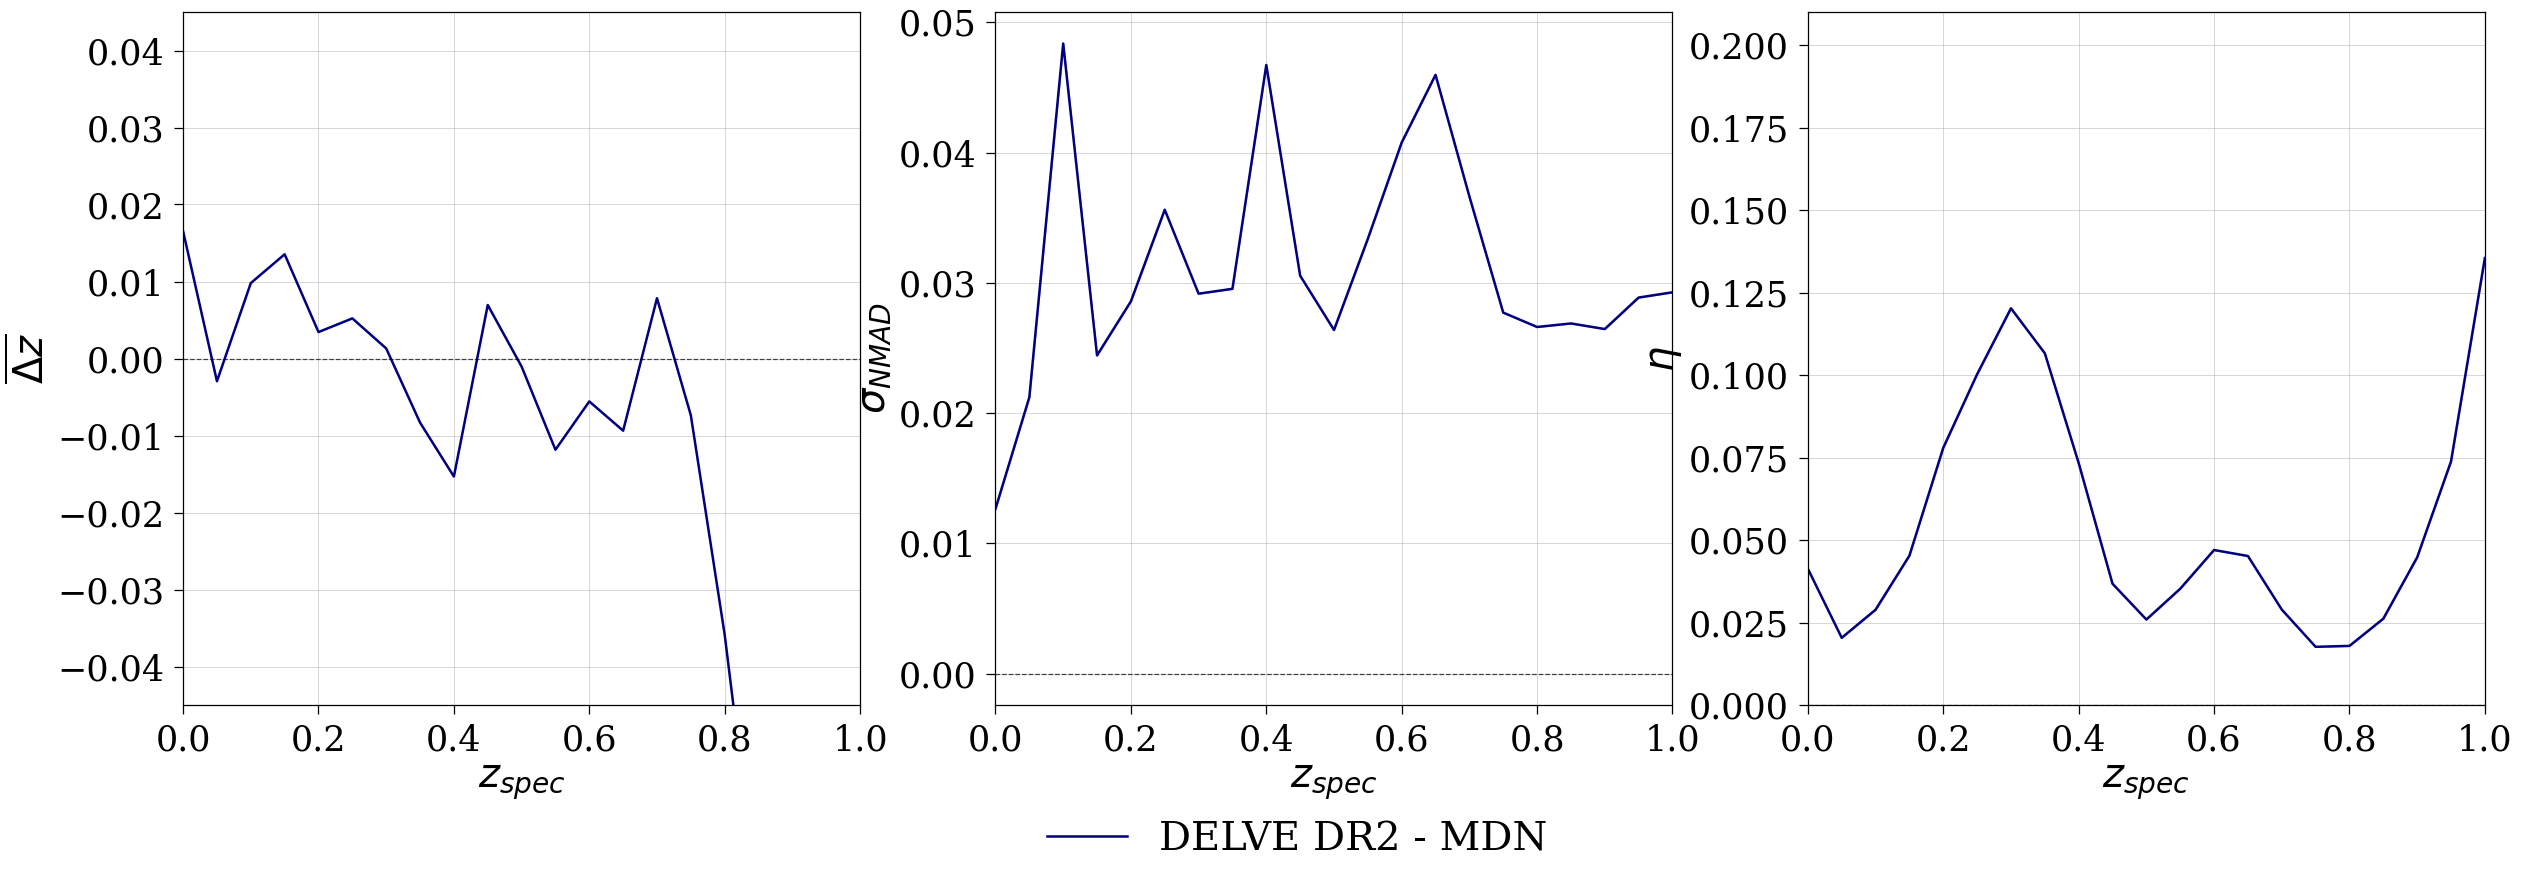

In [6]:
xaxis = 'zspec'

fig, axs = plt.subplots(figsize=(33, 10), dpi=90, nrows=1, ncols=3)

shadow_alpha = 0.2

mdn_style = {
    'color': 'navy',
    'ls': '-',
    'lw': 2,
    'label': 'DELVE DR2 - MDN'
}

legacy_style = {
    'color': 'darkred',
    'ls': '--',
    'lw': 2,
    'label': 'Legacy DR10 - Public'
}

# ------------------------------- MEDIAN BIAS -------------------------------

ax = axs[0]
metric = 'median bias'

ax.plot(bins_DR2[xaxis], metrics_mean_DR2[xaxis][metric], **mdn_style)
ax.fill_between(
    bins_DR2[xaxis],
    metrics_mean_DR2[xaxis][metric] - metrics_std_DR2[xaxis][metric],
    metrics_mean_DR2[xaxis][metric] + metrics_std_DR2[xaxis][metric],
    color=mdn_style['color'],
    alpha=shadow_alpha
)

ax.grid(alpha=0.5)
ax.set_xlim(0.0, 1)
ax.set_ylim(-0.045, 0.045)
ax.axhline(0, c='black', ls='--', alpha=0.7)
ax.set_ylabel('$\\overline{\\Delta z}$', fontsize=32)
ax.set_xlabel('$z_{spec}$', fontsize=32)
ax.tick_params(axis='both', which='major', labelsize=28)
ax.tick_params(axis='y', which='minor', labelsize=28)

# ------------------------------- SIGMA NMAD --------------------------------

ax = axs[1]
metric = '$\\sigma_{NMAD}$'

ax.plot(bins_DR2[xaxis], metrics_mean_DR2[xaxis][metric], **mdn_style)
ax.fill_between(
    bins_DR2[xaxis],
    metrics_mean_DR2[xaxis][metric] - metrics_std_DR2[xaxis][metric],
    metrics_mean_DR2[xaxis][metric] + metrics_std_DR2[xaxis][metric],
    color=mdn_style['color'],
    alpha=shadow_alpha
)

ax.grid(alpha=0.5)
ax.set_xlim(0.0, 1)
ax.axhline(0, c='black', ls='--', alpha=0.7)
ax.set_ylabel('$\\sigma_{NMAD}$', fontsize=32)
ax.set_xlabel('$z_{spec}$', fontsize=32)
ax.tick_params(axis='both', which='major', labelsize=28)
ax.tick_params(axis='y', which='minor', labelsize=28)

# ------------------------------- OUTLIER FRAC ------------------------------

ax = axs[2]
metric = 'outfrac'

ax.plot(bins_DR2[xaxis], metrics_mean_DR2[xaxis][metric], **mdn_style)
ax.fill_between(
    bins_DR2[xaxis],
    metrics_mean_DR2[xaxis][metric] - metrics_std_DR2[xaxis][metric],
    metrics_mean_DR2[xaxis][metric] + metrics_std_DR2[xaxis][metric],
    color=mdn_style['color'],
    alpha=shadow_alpha
)

ax.grid(alpha=0.5)
ax.set_xlim(0.0, 1)
ax.set_ylim(0, 0.21)
ax.axhline(0, c='black', ls='--', alpha=0.7)
ax.set_ylabel('$\\eta$', fontsize=32)
ax.set_xlabel('$z_{spec}$', fontsize=32)
ax.tick_params(axis='both', which='major', labelsize=28)
ax.tick_params(axis='y', which='minor', labelsize=28)

handles, labels = ax.get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    fontsize=32,
    frameon=False,
    loc='lower center',
    ncol=len(labels),
    bbox_to_anchor=(0.5, -0.1)
)

plt.savefig('../figures/metricsXzspec.pdf', bbox_inches='tight')


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Helpers (self-contained)
# -----------------------------
def _pick_col(df, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    raise KeyError(f"None of these columns found: {candidates}")

def snmad(zspec, zphot):
    dz = (zphot - zspec) / (1.0 + zspec)
    med = np.nanmedian(dz)
    return 1.4826 * np.nanmedian(np.abs(dz - med))

def median_bias(zspec, zphot):
    dz = (zphot - zspec) / (1.0 + zspec)
    return np.nanmedian(dz)

def outlier_frac(zspec, zphot, thresh=0.15):
    dz = np.abs(zphot - zspec) / (1.0 + zspec)
    return np.nanmean(dz > thresh)

# -----------------------------
# DR2-only single-axis plot
# -----------------------------
best_fold = folds[0]

# Choose the spectroscopic redshift column name used in your TEST_DATA
zspec_col = _pick_col(TEST_DATA, ["Z", "Z_SPEC", "zspec", "z_spec", "ZSPEC"])
zspec = TEST_DATA[zspec_col].to_numpy()
zphot = np.asarray(My_Photoz[best_fold])

# Basic validity mask
m = np.isfinite(zspec) & np.isfinite(zphot)
zspec = zspec[m]
zphot = zphot[m]

# Metrics
sig_nmad = snmad(zspec, zphot)
med_bias = median_bias(zspec, zphot)
eta = outlier_frac(zspec, zphot)

# Plot
labelsize = 22
fig, ax = plt.subplots(figsize=(8, 7.5), dpi=1500)

hb = ax.hexbin(
    zspec, zphot,
    gridsize=180,
    mincnt=1,
    bins="log"   # log-counts, nice dynamic range
)

# 1:1 and outlier envelope
zmin = max(0.0, np.nanmin(zspec), np.nanmin(zphot))
zmax = .99
zline = np.linspace(zmin, zmax, 200)

ax.plot(zline, zline, ls="--", lw=2)  # 1:1
ax.plot(zline, zline + 0.15*(1+zline), ls="--", lw=2)  # +0.15(1+z)
ax.plot(zline, zline - 0.15*(1+zline), ls="--", lw=2)  # -0.15(1+z)

ax.set_xlabel(r"$z_{\rm spec}$", fontsize=labelsize)
ax.set_ylabel(r"$z_{\rm phot}$", fontsize=labelsize)
ax.tick_params(axis="both", which="major", labelsize=labelsize)
ax.set_xlim(zmin, zmax)
ax.set_ylim(zmin, zmax)
ax.grid(alpha=0.4)

ax.annotate(
    rf"$\sigma_{{\rm NMAD}}$ = {sig_nmad:.3f}   "
    rf"$\delta z$ = {med_bias:.3f}   "
    rf"$\eta$ = {eta:.3f}",
    xy=(0.02, 0.98),
    xycoords="axes fraction",
    va="top", ha="left",
    bbox=dict(boxstyle="round", fc="white", alpha=0.85),
    fontsize=14
)

# Colorbar (bottom)
cb = fig.colorbar(hb, ax=ax, orientation="horizontal", pad=0.2, fraction=0.06)
cb.set_label("n objects (log-binned)", fontsize=labelsize)
cb.ax.tick_params(labelsize=labelsize)

plt.tight_layout()
plt.show()


# PDF Metrics